# Crop Disease Detection - Data Cleaning & Feature Engineering

- **Project:** Crop Disease Detection Using Machine Learning
- **Phase 2 of 3** - Data Cleaning + Feature Engineering
- **Dataset:** crop_disease_dataset.csv (raw, messy)

This notebook focuses on fixing the issues identified in EDA phase, follwed by feature engineering

## 1. Importing Libraries and Raw Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

cropdis= pd.read_csv('crop_disease_dataset.csv')
print("Raw Dataset Shape:",cropdis.shape)
cropdis.head()
cropdis.info()


Raw Dataset Shape: (5000, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   crop_type             5000 non-null   object 
 1   region                3943 non-null   object 
 2   season                3595 non-null   object 
 3   soil_type             3875 non-null   object 
 4   irrigation_method     3785 non-null   object 
 5   temperature_C         4750 non-null   float64
 6   humidity_percent      4800 non-null   float64
 7   rainfall_mm           4750 non-null   float64
 8   leaf_wetness_hrs      4850 non-null   float64
 9   soil_pH               4802 non-null   float64
 10  nitrogen_kg_ha        4800 non-null   float64
 11  phosphorus_kg_ha      4850 non-null   float64
 12  potassium_kg_ha       4850 non-null   float64
 13  days_since_last_rain  4800 non-null   float64
 14  plant_age_days        4850 non-null   floa

## 2. Data Cleaning

### 2.1 Standardise Categorical Columns to Titile Case

`crop_type`,`region`,`season`,`soil_type`,`irrigation_method` each contains 2-3 case variants of same values (e.g 'South','SOUTH', 'south'), which Pandas treat as seperate categories

**Fix**: stripping the empty spaces and converting all the values to title case

In [2]:
cat_cols= ['crop_type','region','season','soil_type','irrigation_method']

print("Before - Unique Values and Count: \n")

for col in cat_cols:
    print(col ,":", cropdis[col].dropna().unique(), ":", len(cropdis[col].unique()), "Variants")
    

Before - Unique Values and Count: 

crop_type : ['maize' 'Cotton' 'cotton' 'Soybean' 'Rice' 'Wheat' 'WHEAT' 'Maize' 'rice'] : 9 Variants
region : ['Central' 'North' 'SOUTH' 'East' 'north' 'South' 'West'] : 8 Variants
season : ['Kharif' 'Rabi' 'kharif' 'RABI' 'Zaid'] : 6 Variants
soil_type : ['Clay' 'CLAY' 'sandy' 'Sandy' 'Loamy' 'loamy' 'Silty'] : 8 Variants
irrigation_method : ['FLOOD' 'Sprinkler' 'Drip' 'drip' 'Rainfed' 'Flood'] : 7 Variants


In [3]:
for col in cat_cols:
    cropdis[col]=cropdis[col].str.strip().str.title()

print("After - Unique Values and Count:\n")

for col in cat_cols:
    print(col,":",cropdis[col].dropna().unique(), ":", len(cropdis[col].unique()), "Variants")


After - Unique Values and Count:

crop_type : ['Maize' 'Cotton' 'Soybean' 'Rice' 'Wheat'] : 5 Variants
region : ['Central' 'North' 'South' 'East' 'West'] : 6 Variants
season : ['Kharif' 'Rabi' 'Zaid'] : 4 Variants
soil_type : ['Clay' 'Sandy' 'Loamy' 'Silty'] : 5 Variants
irrigation_method : ['Flood' 'Sprinkler' 'Drip' 'Rainfed'] : 5 Variants


#### Observations:
- All five columns collapsed to their ture category counts. The Categorical data is now consistent and ready for encoding
  

### 2.2 Treat Out of Range / Physically Implausible Values

We see outliers in various numerical columns like negative temperature, Humidity > 100 %, Negative Fertilizer etc.

**Fix:** Replacing the out of range values with NaN using domain thresolds (dropping the rows would be a bad idea as we would lose valid data
in other columns of the same record)

In [4]:
checks_before = {
    'temperature_C (outside 0–55°C)':    ((cropdis['temperature_C'] < 0) | (cropdis['temperature_C'] > 55)).sum(),
    'humidity_percent (outside 0–100%)': ((cropdis['humidity_percent'] < 0) | (cropdis['humidity_percent'] > 100)).sum(),
    'rainfall_mm (outside 0–500mm)':     ((cropdis['rainfall_mm'] < 0) | (cropdis['rainfall_mm'] > 500)).sum(),
    'soil_pH (outside 3–10)':            ((cropdis['soil_pH'] < 3) | (cropdis['soil_pH'] > 10)).sum(),
    'nitrogen_kg_ha (< 0)':              (cropdis['nitrogen_kg_ha'] < 0).sum(),
    'phosphorus_kg_ha (< 0)':            (cropdis['phosphorus_kg_ha'] < 0).sum(),
    'potassium_kg_ha (< 0)':             (cropdis['potassium_kg_ha'] < 0).sum(),
    'fertilizer_kg_ha (< 0)':            (cropdis['fertilizer_kg_ha'] < 0).sum(),
}
print("Implausible value counts found:\n")
for k, v in checks_before.items():        # .items() returns both the key and value of each dictionary item
    print( k, ":", v, "rows")

Implausible value counts found:

temperature_C (outside 0–55°C) : 30 rows
humidity_percent (outside 0–100%) : 34 rows
rainfall_mm (outside 0–500mm) : 25 rows
soil_pH (outside 3–10) : 17 rows
nitrogen_kg_ha (< 0) : 1 rows
phosphorus_kg_ha (< 0) : 4 rows
potassium_kg_ha (< 0) : 2 rows
fertilizer_kg_ha (< 0) : 43 rows


In [5]:
# series.where(condition) - Keeps the value if condition is ture otherwise replace it with NaN

cropdis['temperature_C']    = cropdis['temperature_C'].where((cropdis['temperature_C'] >= 0) & (cropdis['temperature_C'] <= 55))
cropdis['humidity_percent'] = cropdis['humidity_percent'].where((cropdis['humidity_percent'] >= 0) & (cropdis['humidity_percent'] <= 100))
cropdis['rainfall_mm']      = cropdis['rainfall_mm'].where((cropdis['rainfall_mm'] >= 0) & (cropdis['rainfall_mm'] <= 500))
cropdis['soil_pH']          = cropdis['soil_pH'].where((cropdis['soil_pH'] >= 3) & (cropdis['soil_pH'] <= 10))
cropdis['nitrogen_kg_ha']   = cropdis['nitrogen_kg_ha'].where(cropdis['nitrogen_kg_ha'] >= 0)
cropdis['phosphorus_kg_ha'] = cropdis['phosphorus_kg_ha'].where(cropdis['phosphorus_kg_ha'] >= 0)
cropdis['potassium_kg_ha']  = cropdis['potassium_kg_ha'].where(cropdis['potassium_kg_ha'] >= 0)
cropdis['fertilizer_kg_ha'] = cropdis['fertilizer_kg_ha'].where(cropdis['fertilizer_kg_ha'] >= 0)

print("Implausible values converted to NaN. New null counts in affected columns:\n")
print(cropdis[['temperature_C','humidity_percent','rainfall_mm','soil_pH',
          'nitrogen_kg_ha','phosphorus_kg_ha','potassium_kg_ha','fertilizer_kg_ha']].isnull().sum())

Implausible values converted to NaN. New null counts in affected columns:

temperature_C       280
humidity_percent    234
rainfall_mm         275
soil_pH             215
nitrogen_kg_ha      201
phosphorus_kg_ha    154
potassium_kg_ha     152
fertilizer_kg_ha    243
dtype: int64


### Verifying Temperature and Humidity Before Vs After

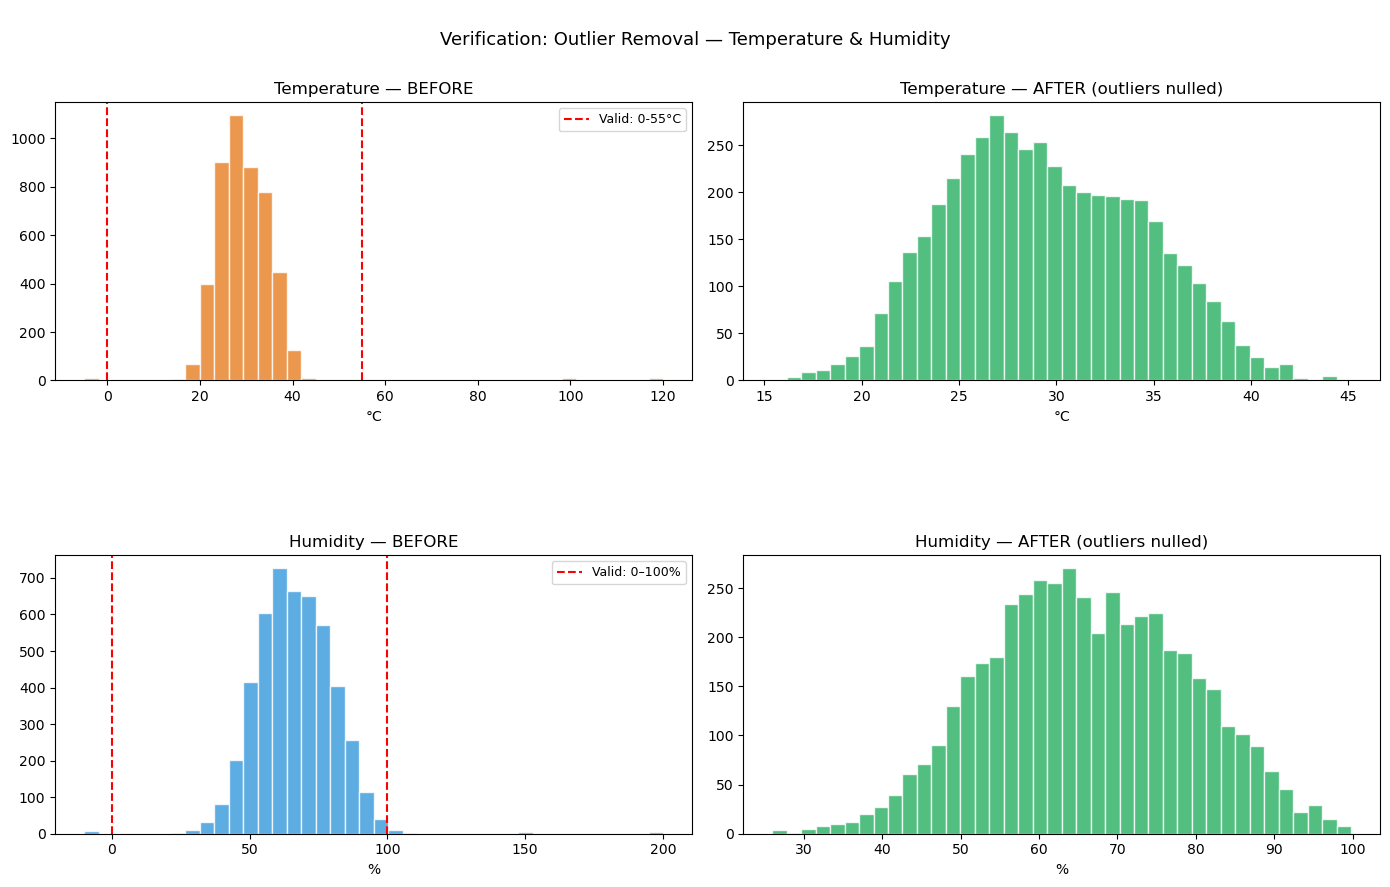

In [6]:
raw = pd.read_csv("crop_disease_dataset.csv")  # original, for visual comparison only

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0,0].hist(raw['temperature_C'].dropna(), bins=40, color='#e67e22', edgecolor='white', alpha=0.8)
axes[0,0].axvline(0,color= 'red', linestyle='--', lw=1.5, label = 'Valid: 0-55°C')
axes[0,0].axvline(55, color='red', linestyle='--', lw=1.5)
axes[0,0].set_title('Temperature — BEFORE')
axes[0,0].set_xlabel('°C'); axes[0,0].legend(fontsize=9)

axes[0,1].hist(cropdis['temperature_C'].dropna(), bins=40, color='#27ae60', edgecolor='white', alpha=0.8)
axes[0,1].set_title('Temperature — AFTER (outliers nulled)')
axes[0,1].set_xlabel('°C')

axes[1,0].hist(raw['humidity_percent'].dropna(), bins=40, color='#3498db', edgecolor='white', alpha=0.8)
axes[1,0].axvline(0, color='red', linestyle='--', lw=1.5, label='Valid: 0–100%')
axes[1,0].axvline(100, color='red', linestyle='--', lw=1.5)
axes[1,0].set_title('Humidity — BEFORE')
axes[1,0].set_xlabel('%'); axes[1,0].legend(fontsize=9)

axes[1,1].hist(cropdis['humidity_percent'].dropna(), bins=40, color='#27ae60', edgecolor='white', alpha=0.8)
axes[1,1].set_title('Humidity — AFTER (outliers nulled)')
axes[1,1].set_xlabel('%')

plt.suptitle('\nVerification: Outlier Removal — Temperature & Humidity\n', fontsize=13)
plt.tight_layout(h_pad=8)
plt.show()

#### Observations:
- The BEFORE temperature plot shows a spike near 120°C which is physically impossible for any farm. After removal, the distribution is a clean bell-curve between 15-45°C. Humidity had values reaching ~200%, after the fix it lies between 25-100%
  

### Verification — Rainfall & Fertilizer Before vs After

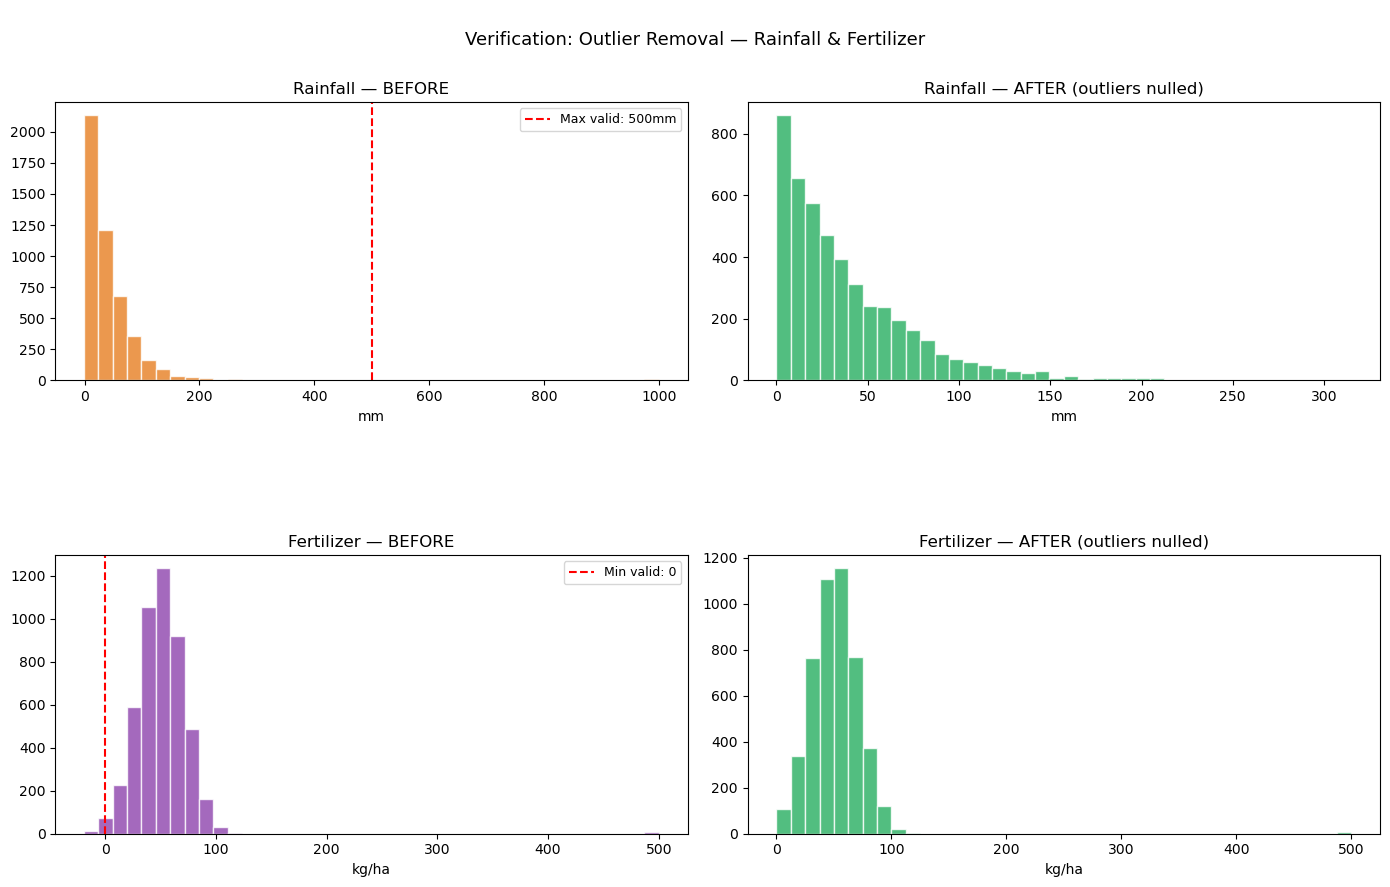

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0,0].hist(raw['rainfall_mm'].dropna(), bins=40, color='#e67e22', edgecolor='white', alpha=0.8)
axes[0,0].axvline(500, color='red', linestyle='--', lw=1.5, label='Max valid: 500mm')
axes[0,0].set_title('Rainfall — BEFORE')
axes[0,0].set_xlabel('mm'); axes[0,0].legend(fontsize=9)

axes[0,1].hist(cropdis['rainfall_mm'].dropna(), bins=40, color='#27ae60', edgecolor='white', alpha=0.8)
axes[0,1].set_title('Rainfall — AFTER (outliers nulled)')
axes[0,1].set_xlabel('mm')

axes[1,0].hist(raw['fertilizer_kg_ha'].dropna(), bins=40, color='#8e44ad', edgecolor='white', alpha=0.8)
axes[1,0].axvline(0, color='red', linestyle='--', lw=1.5, label='Min valid: 0')
axes[1,0].set_title('Fertilizer — BEFORE')
axes[1,0].set_xlabel('kg/ha'); axes[1,0].legend(fontsize=9)

axes[1,1].hist(cropdis['fertilizer_kg_ha'].dropna(), bins=40, color='#27ae60', edgecolor='white', alpha=0.8)
axes[1,1].set_title('Fertilizer — AFTER (outliers nulled)')
axes[1,1].set_xlabel('kg/ha')

plt.suptitle('\nVerification: Outlier Removal — Rainfall & Fertilizer\n', fontsize=13)
plt.tight_layout(h_pad=8)
plt.show()

#### Observations:
Raw rainfall had a value near 999mm in a week — meteorologically impossible. Raw fertilizer had 43 negative entries (data entry errors, since negative quantity has no physical meaning). Both are now clean and ready for imputation.

### 2.3 Imputing Missing Values

**Strategy:**
- **Numerical, Symmetric (|Skew| < 1):** Mean imputation
- **Numerical, skewed (|Skew|>1):** Median Imputaion
- **Categorical Column:** Mode Imputaion

In [8]:
num_cols = ['temperature_C','humidity_percent','rainfall_mm','leaf_wetness_hrs','soil_pH',
            'nitrogen_kg_ha','phosphorus_kg_ha','potassium_kg_ha','days_since_last_rain',
            'plant_age_days','fertilizer_kg_ha']

skew_cropdis = cropdis[num_cols].skew().round(3).to_frame(name='Skewness')  #converting back series to dataframe using to_frame
skew_cropdis['Strategy'] = skew_cropdis['Skewness'].apply(lambda x: 'Median (skewed)' if abs(x) > 1 else 'Mean (symmetric)')
print(skew_cropdis)

                      Skewness          Strategy
temperature_C            0.169  Mean (symmetric)
humidity_percent         0.016  Mean (symmetric)
rainfall_mm              1.941   Median (skewed)
leaf_wetness_hrs        -0.013  Mean (symmetric)
soil_pH                  0.052  Mean (symmetric)
nitrogen_kg_ha           0.000  Mean (symmetric)
phosphorus_kg_ha         0.016  Mean (symmetric)
potassium_kg_ha          0.036  Mean (symmetric)
days_since_last_rain     0.014  Mean (symmetric)
plant_age_days           0.017  Mean (symmetric)
fertilizer_kg_ha         7.978   Median (skewed)


In [9]:
median_cols = ['rainfall_mm','fertilizer_kg_ha']
mean_cols   = [c for c in num_cols if c not in median_cols]  #list comprehension used
print("\n")
for col in median_cols:
    val = cropdis[col].median()
    cropdis[col] = cropdis[col].fillna(val)
    print(col,":","imputed with median = ", round(val,3))

for col in mean_cols:
    val = cropdis[col].mean()
    cropdis[col] = cropdis[col].fillna(val)
    print(col,":","imputed with mean = ", round(val,3))




rainfall_mm : imputed with median =  27.915
fertilizer_kg_ha : imputed with median =  50.68
temperature_C : imputed with mean =  29.429
humidity_percent : imputed with mean =  66.269
leaf_wetness_hrs : imputed with mean =  12.025
soil_pH : imputed with mean =  6.492
nitrogen_kg_ha : imputed with mean =  120.147
phosphorus_kg_ha : imputed with mean =  60.327
potassium_kg_ha : imputed with mean =  80.356
days_since_last_rain : imputed with mean =  29.292
plant_age_days : imputed with mean =  64.261


### 2.3.1 Investigating Categorical Columns Imputation strategy

In [10]:
cat_cols_with_nulls = ['season', 'region', 'soil_type', 'irrigation_method']

for col in cat_cols_with_nulls:
    null_rows   = cropdis[cropdis[col].isnull()]
    total_nulls = len(null_rows)
    dist = null_rows['disease_label'].value_counts()
    pct  = (dist / total_nulls * 100).round(1)
    print("\n")
    print(f"{col} — {total_nulls} nulls:")
    print(pd.DataFrame({'Count': dist, '% of nulls': pct}))
    print()



season — 1405 nulls:
               Count  % of nulls
disease_label                   
Healthy          406        28.9
Bacterial        343        24.4
Fungal           343        24.4
Pest Damage      313        22.3



region — 1057 nulls:
               Count  % of nulls
disease_label                   
Healthy          311        29.4
Bacterial        283        26.8
Fungal           242        22.9
Pest Damage      221        20.9



soil_type — 1125 nulls:
               Count  % of nulls
disease_label                   
Healthy          340        30.2
Fungal           296        26.3
Bacterial        259        23.0
Pest Damage      230        20.4



irrigation_method — 1215 nulls:
               Count  % of nulls
disease_label                   
Healthy          401        33.0
Bacterial        298        24.5
Fungal           271        22.3
Pest Damage      245        20.2



#### Observation:
The missing values in all four columns are proportionately distributed across all disease classes, with no single class showing a significant concentration of null values. Since the missingness is not biased toward any particular disease class, mode imputation is an appropriate method for replacing the null values.

In [20]:
for col in cat_cols_with_nulls:
    mode_val = cropdis[col].mode()[0]
    cropdis[col] = cropdis[col].fillna(mode_val)
    print(col,":","imputed with Mode = ", mode_val)

pest_mode = cropdis['pesticide_applied'].mode()[0]
cropdis['pesticide_applied'] = cropdis['pesticide_applied'].fillna(pest_mode)
print(f'pesticide_applied: imputed with mode = {pest_mode}')

season : imputed with Mode =  Kharif
region : imputed with Mode =  North
soil_type : imputed with Mode =  Loamy
irrigation_method : imputed with Mode =  Drip
pesticide_applied: imputed with mode = 1.0


In [12]:

remaining = cropdis.isnull().sum()
print("\nMissing Values after imputation:\n",remaining)
print("\nShape of the Dataset:", cropdis.shape)


Missing Values after imputation:
 crop_type               0
region                  0
season                  0
soil_type               0
irrigation_method       0
temperature_C           0
humidity_percent        0
rainfall_mm             0
leaf_wetness_hrs        0
soil_pH                 0
nitrogen_kg_ha          0
phosphorus_kg_ha        0
potassium_kg_ha         0
days_since_last_rain    0
plant_age_days          0
pesticide_applied       0
fertilizer_kg_ha        0
disease_label           0
dtype: int64

Shape of the Dataset: (5000, 18)


**Observation:** All 5,000 rows retained, all 18 columns now fully populated. No data was dropped — every record contributes to model training. **Median** imputation for `rainfall_mm` and `fertilizer_kg_ha` avoids inflating values from their heavy right-skew; **Mean** imputation was safe for the remaining near-symmetric columns. **Mode** imputation on `season` filled most nulls with `Kharif`, consistent with the dataset's dominant crops (Rice, Cotton, Maize are primarily Kharif crops) — domain-consistent, not an arbitrary statistical choice.

# 3. Feature Engineering

### 3.1 Create HTI - Heat Humidity Stress Index

Neither humidity nor temperature alone fully captures plant stress — it's their **combination** that drives
fungal/bacterial disease risk (hot + humid conditions accelerate pathogen growth).

**Formula: HTI** = **`HTI = (humidity_percent * temperature_C) / 100`**

count    5000.00
mean       19.45
std         4.64
min         6.70
25%        16.00
50%        19.35
75%        22.63
max        38.40
Name: HTI, dtype: float64


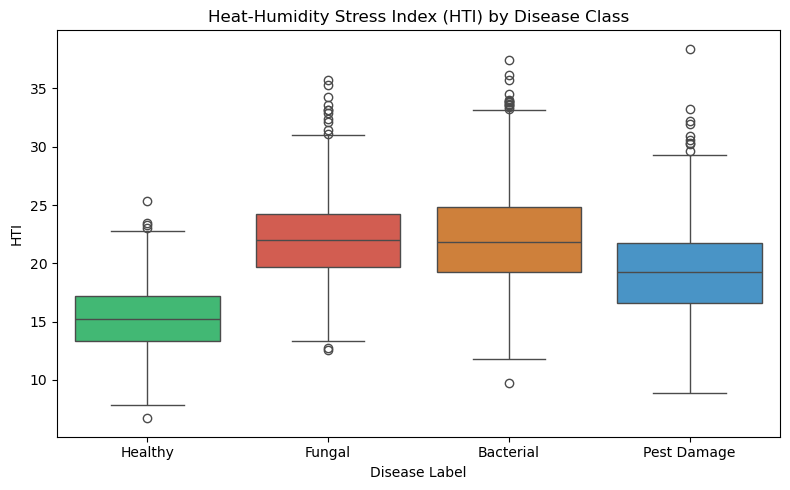

In [13]:
cropdis['HTI'] = (cropdis['humidity_percent'] * cropdis['temperature_C']) / 100
print(cropdis['HTI'].describe().round(2))

fig, ax = plt.subplots(figsize=(8, 5))
palette_class = {'Healthy':'#2ecc71','Fungal':'#e74c3c','Bacterial':'#e67e22','Pest Damage':'#3498db'}
order_class   = ['Healthy','Fungal','Bacterial','Pest Damage']
sns.boxplot(x='disease_label', y='HTI', data=cropdis, order=order_class,
            hue='disease_label', palette=palette_class, legend=False, ax=ax)
ax.set_title('Heat-Humidity Stress Index (HTI) by Disease Class')
ax.set_xlabel('Disease Label')
ax.set_ylabel('HTI')
plt.tight_layout()
plt.show()

#### Observations:
-**HTI** ranges from ~6.7 to 38.4, mean = 19.45.`Fungal` and `Bacterial` classes show visibly higher median `HTI` than `Healthy` and `Pest Damage`
-This confirms that combines heat - humidity stress is a meaningfull disease signal.

### 3.2 Creating Drought_Stress - Dry spell indicator

A long gap since rain combined with low recent rainfall is a strong drought signal.

**Drought_stress = 1 if(days_since_last_rain > 20) AND (rainfall_mm < 10), else 0**

In [14]:
cropdis['drought_stress'] = ((cropdis['days_since_last_rain']>20) & (cropdis['rainfall_mm']<10)).astype(int) # type casting the output

print(cropdis['drought_stress'].value_counts())

drought_stress
0    4309
1     691
Name: count, dtype: int64


In [15]:
ct = (cropdis.groupby('disease_label')['drought_stress'].value_counts(normalize=True).unstack()*100) #normalize calculated % instead of counts
ct.columns = ['No Drought Stress %', 'Drought Stress %']  #renaming the columns
print(ct.round(1))


               No Drought Stress %  Drought Stress %
disease_label                                       
Bacterial                     86.4              13.6
Fungal                        86.0              14.0
Healthy                       86.5              13.5
Pest Damage                   85.6              14.4


#### Observations:
-691 records (13.8%) are flagged as drought-stressed. The `pest damage` class shows a noticeably higher drought-stress rate compared to 
other classes.
-This is in accrodance with our general understanding that dry conditions correlate with Pest activity. 

### 3.3 Create maturity_stage = Plant Growth stage (Label Encoded)

**Plant age is grouped into three biologically meaningful growth stages**, as disease susceptibility often changes throughout a plant's life cycle.
Since these stages follow a natural progression **(Seedling → Vegetative → Reproductive), they are label encoded (0, 1, 2)** to preserve their
ordinal relationship while making the feature suitable for machine learning models.

**Rule:**
- `< 30 days` → Seedling
- `30–70 days` → Vegetative
- `> 70 days` → Reproductive

In [16]:
def get_maturity_stage(days):
    if days < 30:
        return 'Seedling'
    elif days <= 70:
        return 'Vegetative'
    else:
        return 'Reproductive'

cropdis['maturity_stage'] = cropdis['plant_age_days'].apply(get_maturity_stage)  #apply functions to every row in the column

stage_order = {'Seedling': 0, 'Vegetative': 1, 'Reproductive': 2}  # a dictionary help in converting text labels to numbers
cropdis['maturity_stage_encoded'] = cropdis['maturity_stage'].map(stage_order)  #replacing each value using dictionary 

print(cropdis['maturity_stage'].value_counts())

print("Verifying Mapping:\n")
print(cropdis[['plant_age_days','maturity_stage','maturity_stage_encoded']].head(10))

maturity_stage
Reproductive    2141
Vegetative      1977
Seedling         882
Name: count, dtype: int64
Verifying Mapping:

   plant_age_days maturity_stage  maturity_stage_encoded
0            22.0       Seedling                       0
1            13.0       Seedling                       0
2            31.0     Vegetative                       1
3           116.0   Reproductive                       2
4            84.0   Reproductive                       2
5            46.0     Vegetative                       1
6            23.0       Seedling                       0
7           115.0   Reproductive                       2
8            19.0       Seedling                       0
9            33.0     Vegetative                       1


#### Observations:
**Reproductive** is largest group **(2,141 records)**, followed by **Vegetative (1,977 records)** and **seeding (882)**. **Label Encoding** is accurate than OHE here because the three stages have natural heirarchy or relationship. A model can naturally interpret 0<1<2 as a progression through plant growth, which One Hot Econding would discard.

### 3.4 ONE HOT ENCODING remaining Categorical Columns


- **Columns to encode:** `crop_type`, `region`, `season`, `soil_type`, `irrigation_method`
- `maturity_stage` is not included as `maturity_stage_encoded` represent it numerically

**Why One-Hot Encoding (OHE) instead of Label Encoding here:**

These five columns are **nominal** — their categories have **no inherent order**. `crop_type` values (Rice, Wheat, Maize, Cotton, Soybean) aren't ranked; `region` (North, South, East, West, Central) has no hierarchy. 

If we used Label Encoding instead (e.g. Rice=0, Wheat=1, Maize=2...), the model would wrongly interpret this as Maize being "greater than" Rice — introducing a false ordinal relationship that doesn't exist and can mislead distance-based or tree-split models. OHE avoids this by creating a separate binary column per category, with no implied ranking.

This is the opposite case from `maturity_stage` above, where the categories genuinely *are* ordered — hence Label Encoding was appropriate there, but not here.

In [17]:
ohe_cols = ['crop_type', 'region', 'season', 'soil_type', 'irrigation_method']

cropdis_encoded = pd.get_dummies(cropdis, columns = ohe_cols, drop_first = False)

cropdis_encoded = cropdis_encoded.drop(columns = ['maturity_stage']) #Test version of maturity_stage

print("\nShape after One Hot Encoding: ",cropdis_encoded.shape)
cropdis_encoded.info()


Shape after One Hot Encoding:  (5000, 37)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 37 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   temperature_C                5000 non-null   float64
 1   humidity_percent             5000 non-null   float64
 2   rainfall_mm                  5000 non-null   float64
 3   leaf_wetness_hrs             5000 non-null   float64
 4   soil_pH                      5000 non-null   float64
 5   nitrogen_kg_ha               5000 non-null   float64
 6   phosphorus_kg_ha             5000 non-null   float64
 7   potassium_kg_ha              5000 non-null   float64
 8   days_since_last_rain         5000 non-null   float64
 9   plant_age_days               5000 non-null   float64
 10  pesticide_applied            5000 non-null   float64
 11  fertilizer_kg_ha             5000 non-null   float64
 12  disease_label                5000

### Observations:
One-Hot Encoding expanded the 5 nominal columns (22 raw category values combined) into 21 binary indicator columns, taking the dataset from 22 to ~38 columns.

### **Summary:**
Missing values, inconsistent entries, and implausible values were identified and handled using appropriate imputation techniques and validation rules. New meaningful features, such as `maturity_stage`, were created to capture domain-specific insights, while categorical variables were encoded using **Label Encoding** or **One-Hot Encoding** based on their characteristics. These preprocessing steps produced a clean, structured, and machine learning–ready dataset for model training and evaluation.

In [18]:
cropdis.to_csv("crop_cleaned_dataset.csv", index=False)
print("File saved successfully")

File saved successfully
